# Case
**Creates binary rasters to be used as templates for data alignment**

In this case, we use the high-res geophysical data footprint to create the template raster.

In [11]:
import geopandas as gpd
from beak.utilities.io import data_folder

**User definitions**

In [12]:
# Path to base data folder
BASE_PATH = data_folder()

# Path to footprint raster
INPUT_FILE = BASE_PATH / "RAW" / "geophysics" / "regional_scale" / "alaska_ytu" / "magnetic" / "Mag_RTP_HGM_YTU.tif"

# Set outut settings
EPSG = 102008
RESOLUTION = 100
DESCRIPTION = "ALASKA_YTU_SNAP"

# Out file path
OUT_FILE = BASE_PATH / "BASE_RASTERS" / f"EPSG_{EPSG}_RES_{RESOLUTION}_{DESCRIPTION}.tif"


**Create mask**

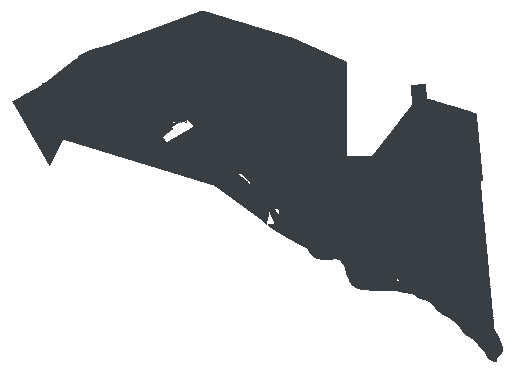

In [13]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from beak.utilities.raster_processing import snap_raster

raster = rasterio.open(INPUT_FILE)
raster_array = raster.read()

# Snap to origin
raster_array, raster_meta = snap_raster(raster, (0, 0))

# Binarize and set new nodata value
raster_array = np.where(raster_array != raster.nodata, 1, -99)

# Plot
cmap = ListedColormap(["white", "#383e42"])
cmap.set_bad("black")
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.imshow(raster_array.squeeze(), cmap=cmap)
ax.axis("off")
plt.show()


In [14]:
from beak.utilities.io import save_raster

# Save raster
save_raster(path=OUT_FILE, array=raster_array, nodata_value=NODATA, dtype="int8", metadata=raster_meta)